In [3]:
pip install xgboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.5 MB/s eta 0:00:00


In [4]:
pip install datasets

In [5]:
from datasets import load_dataset

ds = load_dataset("mahmoudalyosify/SCRAP")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/399 [00:00<?, ?B/s]

train_data.csv:   0%|          | 0.00/234M [00:00<?, ?B/s]

test_data.csv:   0%|          | 0.00/35.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/162634 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24484 [00:00<?, ? examples/s]

In [6]:
pip install seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split,cross_val_score,GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,mean_squared_error
import optuna
pd.set_option('display.max_columns', None, 'display.max_rows', None)

In [8]:
df_train=pd.DataFrame(ds['train'])
df_test=pd.DataFrame(ds['test'])


In [70]:
df_test.iloc[1849]

,1849
event_id,1.700000e+02
time_to_tca,6.067876e+00
mission_id,2.000000e+00
risk,-9.121248e+00
max_risk_estimate,-5.130475e+00
max_risk_scaling,1.278779e+01
miss_distance,1.303000e+03
relative_speed,1.465500e+04
relative_position_r,-2.521000e+02
relative_position_t,-2.190000e+02


In [10]:
def preprocessing(df):
  num_cols = df.select_dtypes(include='number').columns
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())
  df['c_object_type']=df['c_object_type'].fillna(df['c_object_type'].mode()[0])
  mapping = {
    'UNKOWN': 1,
    'TBA': 2,
    'ROCKET BODY': 3,
    'PAYLOAD':4,
    'DEBRIS':5
  }
  df['c_object_type']=df['c_object_type'].map(mapping)
  return df

In [11]:
def filtering (df,df_train):
  train=df[df['time_to_tca']>=2]
  train = train.sort_values(['event_id', 'time_to_tca'], ascending=[True, False])
  feature=train.drop(columns=['event_id','max_risk_estimate','max_risk_scaling'])
  corr = df_train.corr().abs()
  upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

  to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
  feature=feature.drop(columns=to_drop)
  groups = train.groupby("event_id")
  return feature,groups

In [47]:
def feature_engineering(groups, feature):
    features = []
    targets = []

    for eid, g in groups:
        g = g.sort_values('time_to_tca', ascending=False)

        first = g.iloc[0]
        last  = g.iloc[-1]
        feat = {}

        targets.append(last['risk'])

        g_features = g.iloc[:-1] if len(g) > 1 else g

        first_f = g_features.iloc[0]
        last_f  = g_features.iloc[-1]

        dt = first_f['time_to_tca'] - last_f['time_to_tca']
        dt = max(dt, 1e-6)

        for col in feature:
            if col in ['mission_id', 'c_object_type']:
                feat[col + "_last"] = last_f[col]
                continue

            if len(g_features) < 2:
                feat[col + "_last"]  = last_f[col]
                feat[col + "_mean"]  = last_f[col]
                feat[col + "_std"]   = 0.0
                feat[col + "_min"]   = last_f[col]
                feat[col + "_max"]   = last_f[col]
                feat[col + "_delta"] = 0.0
                feat[col + "_slope"] = 0.0
                feat[col + "_last2_change"]   = 0.0
                feat[col + "_change_ratio"]   = 0.0
                feat[col + "_recent_vs_early"] = 0.0
                feat[col + "_max_single_jump"] = 0.0
                continue

            series = g_features[col]
            diffs  = series.diff().dropna()

            feat[col + "_last"]  = last_f[col]
            feat[col + "_mean"]  = series.mean()
            feat[col + "_std"]   = series.std()
            feat[col + "_min"]   = series.min()
            feat[col + "_max"]   = series.max()
            feat[col + "_delta"] = last_f[col] - first_f[col]
            feat[col + "_slope"] = (last_f[col] - first_f[col]) / dt

            # التغيير بين آخر CDMين
            last2_change = series.iloc[-1] - series.iloc[-2]
            feat[col + "_last2_change"] = last2_change

            # نسبة التغيير الأخير مقارنة بالمعدل
            mean_change = diffs.mean() if len(diffs) > 0 else 0
            feat[col + "_change_ratio"] = last2_change / (abs(mean_change) + 1e-9)

            # آخر 3 CDMs مقارنة بأول 3
            if len(series) >= 6:
                feat[col + "_recent_vs_early"] = (
                    series.iloc[-3:].mean() - series.iloc[:3].mean()
                )
            else:
                feat[col + "_recent_vs_early"] = (
                    series.iloc[-1] - series.iloc[0]
                )

            # أكبر قفزة في خطوة واحدة
            feat[col + "_max_single_jump"] = diffs.max() if len(diffs) > 0 else 0.0

        features.append(feat)

    X = pd.DataFrame(features)
    y = np.array(targets)

    return X, y

In [48]:
df_test=preprocessing(df_test)
df_train=preprocessing(df_train)

In [49]:
df_train.shape

(162634, 103)

In [50]:
f,g=filtering(df_test,df_train)
m,n=filtering(df_train,df_train)

In [16]:
m.shape

(111939, 75)

In [17]:
m.shape

(111939, 75)

In [51]:
X_test,y_test=feature_engineering(g,f)
X_train,y_train=feature_engineering(n,m)

In [53]:
X_test.shape

(2167, 805)

In [19]:
X_train.shape

(11942, 513)

In [54]:
y_train_1D = pd.DataFrame(np.squeeze(y_train))
y_test_1D  = np.squeeze(y_test)

count    13154.000000
mean        12.363844
std          7.512551
min          1.000000
25%          5.000000
50%         13.000000
75%         20.000000
max         23.000000
dtype: float64
                  0
count  11942.000000
mean     -20.047673
std        9.970397
min      -30.000000
25%      -30.000000
50%      -21.665346
75%       -9.508499
max       -1.684660


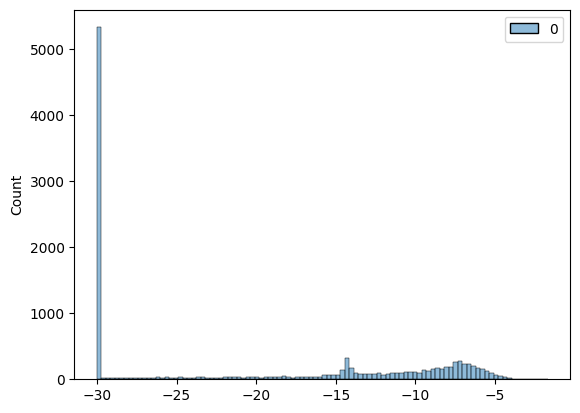

risk_last                      0.873971
risk_min                       0.829798
risk_mean                      0.714606
risk_std                       0.660973
risk_delta                     0.636557
risk_recent_vs_early           0.624064
risk_slope                     0.395133
time_to_tca_recent_vs_early    0.386888
time_to_tca_delta              0.382349
c_time_lastob_end_min          0.376736
time_to_tca_std                0.372342
time_to_tca_min                0.368717
time_to_tca_last               0.368717
c_time_lastob_end_last         0.358010
c_time_lastob_start_last       0.349201
c_time_lastob_start_min        0.338751
risk_max                       0.334786
c_ct_r_std                     0.300776
c_cn_r_std                     0.287090
c_time_lastob_end_mean         0.281179
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [55]:
print(df_train.groupby('event_id').size().describe())  # how many obs per event?
print(y_train_1D.describe())                              # risk is heavily negative → maybe log-transform?
sns.histplot(y_train_1D, bins=100)
plt.show()

# Correlation with target

corr = X_train.corrwith(pd.Series(y_train)).abs().sort_values(ascending=False)

print(corr.head(20))

In [57]:

import numpy as np
import pandas as pd
X_train.fillna(X_train.median(),inplace=True)
X_test.fillna(X_test.median(),inplace=True)
print("inf---------------------",np.isinf(X_train).sum())

print("none---------------------",np.isnan(X_train).sum())

print("max----------------------",np.max(np.abs(X_train)))


inf--------------------- time_to_tca_last                             0
time_to_tca_mean                             0
time_to_tca_std                              0
time_to_tca_min                              0
time_to_tca_max                              0
time_to_tca_delta                            0
time_to_tca_slope                            0
time_to_tca_last2_change                     0
time_to_tca_change_ratio                     0
time_to_tca_recent_vs_early                  0
time_to_tca_max_single_jump                  0
mission_id_last                              0
risk_last                                    0
risk_mean                                    0
risk_std                                     0
risk_min                                     0
risk_max                                     0
risk_delta                                   0
risk_slope                                   0
risk_last2_change                            0
risk_change_ratio                  

In [58]:
X_train = np.clip(X_train, -1e15, 1e15)

In [59]:
X_test = np.clip(X_test, -1e15, 1e15)

## importing gradient descent

In [25]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 0.8),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "tree_method": "hist",
        "device": "cuda",
        "random_state": 42
    }

    weight_value = trial.suggest_float("weight_value", 5.0, 50.0)  # ← Optuna يختار الوزن

    model = xgb.XGBRegressor(**params)

    gkf = GroupKFold(n_splits=5)
    losses = []

    for train_idx, val_idx in gkf.split(X_train, y_train.flatten(),
                                         groups=X_train['mission_id_last']):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.flatten()[train_idx]
        y_val = y_train.flatten()[val_idx]

        # sample weights
        weights = np.where(y_tr >= -6, weight_value, 1.0)

        model.fit(X_tr, y_tr, sample_weight=weights)
        pred = model.predict(X_val)

        # competition loss على الـ validation
        high_mask = y_val >= -6
        if high_mask.sum() == 0:
            continue

        # F2
        y_true_bin = (y_val >= -6).astype(int)
        y_pred_bin = (pred  >= -6).astype(int)
        precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        recall    = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f2 = (5 * precision * recall) / (4 * precision + recall + 1e-9)

        # MSE على high-risk فقط
        mse = mean_squared_error(y_val[high_mask], pred[high_mask])

        loss = (1 / (f2 + 1e-9)) * mse
        losses.append(loss)

    return np.mean(losses)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best Loss:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-03-03 12:37:22,879] A new study created in memory with name: no-name-4e3b66f1-019f-485b-b53e-d8141e960361


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-03 12:37:41,347] Trial 0 finished with value: 25.7780557635078 and parameters: {'n_estimators': 519, 'max_depth': 5, 'learning_rate': 0.034637811464593535, 'subsample': 0.6889224345400039, 'colsample_bytree': 0.431962137631223, 'reg_lambda': 1.2723858708028655, 'reg_alpha': 0.46778855230996297, 'min_child_weight': 14, 'gamma': 0.8982774279857795, 'weight_value': 40.54153888831014}. Best is trial 0 with value: 25.7780557635078.
[I 2026-03-03 12:38:00,815] Trial 1 finished with value: 33.17439708952285 and parameters: {'n_estimators': 689, 'max_depth': 4, 'learning_rate': 0.08078403093186749, 'subsample': 0.741503560729145, 'colsample_bytree': 0.6550247493995751, 'reg_lambda': 3.262986153495107, 'reg_alpha': 0.0315284228492565, 'min_child_weight': 18, 'gamma': 0.01677268014610256, 'weight_value': 34.518476460547355}. Best is trial 0 with value: 25.7780557635078.
[I 2026-03-03 12:38:27,917] Trial 2 finished with value: 19.00111065592506 and parameters: {'n_estimators': 996, 'ma

In [60]:
best_params ={'n_estimators': 417, 'max_depth': 3, 'learning_rate': 0.01016749337196399, 'subsample': 0.6510247012658068, 'colsample_bytree': 0.5977034183150768, 'reg_lambda': 2.670752418125512, 'reg_alpha': 0.02853632079225546, 'min_child_weight': 9, 'gamma': 0.7312792763971115, 'weight_value': 35.96498766484235}


weight_value = best_params.pop("weight_value")  # يشيله من الـ dict

weights = np.where(y_train.flatten() >= -6, weight_value, 1.0)

final_model = xgb.XGBRegressor(
    **best_params,
    tree_method='hist',
    device='cuda',
    random_state=42
)

final_model.fit(
    X_train,
    y_train.flatten(),
    sample_weight=weights,

)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:43:07] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:43:07] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5977034183150768, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.7312792763971115, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01016749337196399,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=9, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=417, n_jobs=None,
             num_parallel_tree=None, ...)

In [62]:
prediction=final_model.predict(X_test)
high_mask_train = y_train.flatten() >= -6
print(f"High-risk training samples: {high_mask_train.sum()}")

X_train_high = X_train[high_mask_train]
y_train_high = y_train.flatten()[high_mask_train]

specialist = xgb.XGBRegressor(
     n_estimators=3000,      # أكتر trees
    max_depth=6,            # أعمق = يلتقط patterns دقيقة
    learning_rate=0.003,    # أبطأ = أدق
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=0.3,         # regularization أقل
    reg_alpha=0.0,
    min_child_weight=1,     # يسمح بـ splits أصغر
    tree_method='hist',
    random_state=42

)

specialist.fit(X_train_high, y_train_high)

# ── Step 3: استخدم الـ specialist للأحداث الخطيرة فقط ────────
prediction_final = prediction.copy()
high_mask_test = prediction >= -6  # الأحداث اللي الموديل الأول صنفها خطيرة
prediction_final[high_mask_test] = specialist.predict(X_test[high_mask_test])

# ── Step 4: قيّم ──────────────────────────────────────────────
print("\n=== Before Specialist ===")
competition_loss(y_test.flatten(), prediction)

print("\n=== After Specialist ===")
competition_loss(y_test.flatten(), prediction_final)

High-risk training samples: 569

=== Before Specialist ===
Threshold:        r >= -6 (10^-6)
High-risk events: 178 / 2167
Precision:        0.8060
Recall:           0.9101
F2 Score:         0.8872
MSE (high-risk):  7.764421
Final Loss L:     8.751749

=== After Specialist ===
Threshold:        r >= -6 (10^-6)
High-risk events: 178 / 2167
Precision:        0.8060
Recall:           0.9101
F2 Score:         0.8872
MSE (high-risk):  7.576584
Final Loss L:     8.540026


8.54002574380797

In [66]:
high_mask = y_test.flatten() >= -6
high_indices = np.where(high_mask)[0]

y_true_high = y_test.flatten()[high_mask]
y_pred_high = prediction[high_mask]

errors = np.abs(y_true_high - y_pred_high)
worst_idx = np.argsort(errors)[-20:]

print("أكبر أخطاء:")
for i in worst_idx:
    real_idx = high_indices[i]
    print(f"  idx={real_idx}, "
          f"y_true={y_true_high[i]:.2f}, "   # ← الصح
          f"y_pred={y_pred_high[i]:.2f}, "
          f"error={errors[i]:.2f}")

أكبر أخطاء:
  idx=1792, y_true=-3.38, y_pred=-4.68, error=1.30
  idx=2091, y_true=-3.14, y_pred=-4.46, error=1.32
  idx=1174, y_true=-5.55, y_pred=-6.86, error=1.32
  idx=1326, y_true=-5.26, y_pred=-6.59, error=1.32
  idx=1166, y_true=-3.86, y_pred=-5.19, error=1.33
  idx=2117, y_true=-3.52, y_pred=-4.87, error=1.35
  idx=2059, y_true=-3.10, y_pred=-4.46, error=1.35
  idx=1568, y_true=-2.99, y_pred=-4.43, error=1.44
  idx=891, y_true=-2.89, y_pred=-4.41, error=1.52
  idx=466, y_true=-5.22, y_pred=-7.17, error=1.95
  idx=276, y_true=-5.10, y_pred=-7.08, error=1.98
  idx=1448, y_true=-3.04, y_pred=-5.06, error=2.01
  idx=109, y_true=-5.58, y_pred=-7.76, error=2.18
  idx=1984, y_true=-3.21, y_pred=-5.43, error=2.22
  idx=1525, y_true=-5.18, y_pred=-8.23, error=3.05
  idx=512, y_true=-3.84, y_pred=-6.98, error=3.14
  idx=968, y_true=-5.41, y_pred=-8.74, error=3.33
  idx=1849, y_true=-5.88, y_pred=-25.18, error=19.31
  idx=1546, y_true=-5.64, y_pred=-25.05, error=19.41
  idx=42, y_true=-5.8

In [68]:
# شوف features الـ worst case
print(X_test.iloc[1849])

time_to_tca_last                             2.597642e+00
time_to_tca_mean                             4.640327e+00
time_to_tca_std                              1.303346e+00
time_to_tca_min                              2.597642e+00
time_to_tca_max                              6.676485e+00
time_to_tca_delta                           -4.078843e+00
time_to_tca_slope                           -1.000000e+00
time_to_tca_last2_change                    -4.043857e-01
time_to_tca_change_ratio                    -1.189707e+00
time_to_tca_recent_vs_early                 -3.347675e+00
time_to_tca_max_single_jump                 -2.791116e-01
mission_id_last                              7.000000e+00
risk_last                                   -3.000000e+01
risk_mean                                   -1.352670e+01
risk_std                                     1.144247e+01
risk_min                                    -3.000000e+01
risk_max                                    -5.654234e+00
risk_delta    

In [40]:
# شوف الأحداث اللي فيها أكبر خطأ
high_mask = y_test.flatten() >= -6
errors = np.abs(y_test.flatten()[high_mask] - prediction[high_mask])
worst_idx = np.argsort(errors)[-20:]  # أسوأ 20 حدث

print("أكبر أخطاء:")
for i in worst_idx:
    print(f"  y_true={y_test.flatten()[high_mask][i]:.2f}, "
          f"y_pred={prediction[high_mask][i]:.2f}, "
          f"error={errors[i]:.2f}")

أكبر أخطاء:
  y_true=-3.86, y_pred=-5.14, error=1.28
  y_true=-3.38, y_pred=-4.68, error=1.29
  y_true=-3.10, y_pred=-4.41, error=1.31
  y_true=-5.55, y_pred=-6.88, error=1.33
  y_true=-2.99, y_pred=-4.33, error=1.34
  y_true=-5.33, y_pred=-6.70, error=1.37
  y_true=-2.89, y_pred=-4.32, error=1.43
  y_true=-3.21, y_pred=-4.79, error=1.58
  y_true=-5.55, y_pred=-7.16, error=1.61
  y_true=-3.04, y_pred=-4.71, error=1.67
  y_true=-5.26, y_pred=-7.10, error=1.84
  y_true=-5.10, y_pred=-7.27, error=2.18
  y_true=-5.58, y_pred=-7.83, error=2.25
  y_true=-5.22, y_pred=-7.65, error=2.43
  y_true=-5.41, y_pred=-8.63, error=3.22
  y_true=-3.84, y_pred=-7.43, error=3.60
  y_true=-5.18, y_pred=-9.60, error=4.42
  y_true=-5.64, y_pred=-25.43, error=19.79
  y_true=-5.88, y_pred=-25.67, error=19.80
  y_true=-5.89, y_pred=-28.17, error=22.29


In [44]:
competition_loss(y_test.flatten(), prediction_final)

Threshold:        r >= -6 (10^-6)
High-risk events: 178 / 2167
Precision:        0.8712
Recall:           0.6461
F2 Score:         0.6813
MSE (high-risk):  9.636096
Final Loss L:     14.144114


14.144113699372593

In [64]:
from sklearn.metrics import precision_score, recall_score, mean_squared_error

def competition_loss(y_true, y_pred, beta=2):
    """
    Official competition loss: L = (1/F2) * MSE
    - Threshold: r >= -6 (log scale equivalent of 10^-6)
    - MSE: only on high-risk events
    - F2: over whole dataset
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    threshold = -6  # log10(10^-6) = -6

    # Step 1: Binary classification over whole dataset
    y_true_bin = (y_true >= threshold).astype(int)  # 1 = high risk
    y_pred_bin = (y_pred >= threshold).astype(int)

    # Step 2: F2 score
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall    = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    if precision == 0 and recall == 0:
        f2 = 0
    else:
        f2 = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)

    # Step 3: MSE only on HIGH-RISK events
    high_risk_mask = y_true >= threshold

    if high_risk_mask.sum() == 0:
        print("Warning: No high-risk events found!")
        return float('inf')

    mse = mean_squared_error(
        y_true[high_risk_mask],
        y_pred[high_risk_mask]
    )

    # Step 4: Final loss
    if f2 == 0:
        loss = float('inf')
    else:
        loss = (1 / f2) * mse

    # Report
    print(f"Threshold:        r >= -6 (10^-6)")
    print(f"High-risk events: {high_risk_mask.sum()} / {len(y_true)}")
    print(f"Precision:        {precision:.4f}")
    print(f"Recall:           {recall:.4f}")
    print(f"F2 Score:         {f2:.4f}")
    print(f"MSE (high-risk):  {mse:.6f}")
    print(f"Final Loss L:     {loss:.6f}")

    return loss

# Evaluate
prediction=final_model.predict(X_test)
clip_thresholds = [-7, -8, -9, -10, -12, -15]

print("Clip Val | MSE      | Loss")
print("-" * 35)

for clip_val in clip_thresholds:
    pred_clipped = np.clip(prediction, clip_val, None)

    # احسب على high-risk فقط
    high_risk_mask = y_test >= -6
    pred_hr = pred_clipped[high_risk_mask]
    true_hr = y_test[high_risk_mask]

    mse = np.mean((pred_hr - true_hr) ** 2)

    # احسب F2 (مش بتتغير بالـ clipping على الـ threshold)
    pred_binary = (pred_clipped >= -6).astype(int)
    true_binary = (y_test >= -6).astype(int)

    tp = np.sum((pred_binary == 1) & (true_binary == 1))
    fp = np.sum((pred_binary == 1) & (true_binary == 0))
    fn = np.sum((pred_binary == 0) & (true_binary == 1))

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f2 = (5 * precision * recall) / (4 * precision + recall + 1e-9)

    loss = (1/f2) * mse if f2 > 0 else float('inf')
    print(f"  {clip_val:4d}   | {mse:.6f} | {loss:.6f}")

# بدون clipping
pred_hr = final_pred[y_test >= -6]
true_hr = y_test[y_test >= -6]
mse_no_clip = np.mean((pred_hr - true_hr) ** 2)
print(f"No clip  | {mse_no_clip:.6f} | {8.54:.6f}")

print("=== Test Set ===")
#loss = competition_loss(y_test, prediction)


Clip Val | MSE      | Loss
-----------------------------------
    -7   | 0.491583 | 0.554093
    -8   | 0.619192 | 0.697928
    -9   | 0.742485 | 0.836900
   -10   | 0.867168 | 0.977438
   -12   | 1.217658 | 1.372496
   -15   | 1.996202 | 2.250040


NameError: name 'final_pred' is not defined